## Day-1

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io

# Read the uploaded CSV file into a DataFrame
df = pd.read_csv('/content/creditcard.csv')

# Basic info
print(df.shape)           # How many rows and columns?
print(df.head())          # What does the data look like?
print(df.dtypes)          # What types are the columns?
print(df.isnull().sum())  # Any missing values?

(89220, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V2

Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.1727%


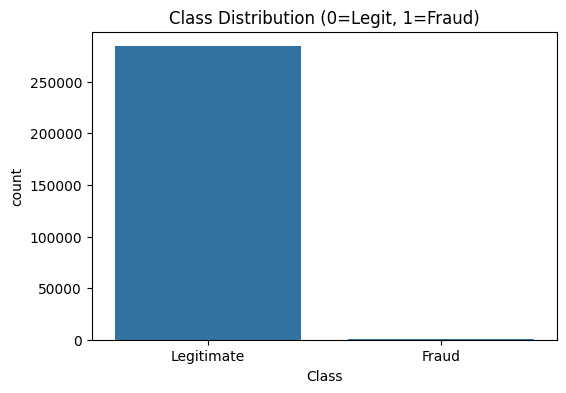

In [ ]:
fraud_count = df['Class'].value_counts()
print(fraud_count)
print(f"\nFraud percentage: {fraud_count[1] / len(df) * 100:.4f}%")

# Visualize it
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title('Class Distribution (0=Legit, 1=Fraud)')
plt.xticks([0, 1], ['Legitimate', 'Fraud'])
plt.show()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


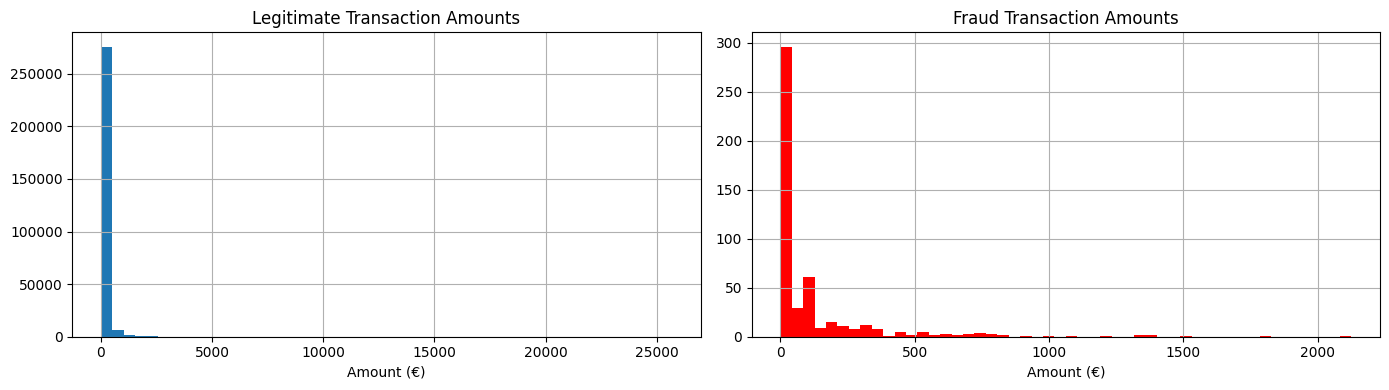


Average legitimate amount: 88.29
Average fraud amount: 122.21


In [ ]:
print(df['Amount'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution for legitimate
df[df['Class'] == 0]['Amount'].hist(bins=50, ax=axes[0])
axes[0].set_title('Legitimate Transaction Amounts')
axes[0].set_xlabel('Amount (€)')

# Distribution for fraud
df[df['Class'] == 1]['Amount'].hist(bins=50, ax=axes[1], color='red')
axes[1].set_title('Fraud Transaction Amounts')
axes[1].set_xlabel('Amount (€)')

plt.tight_layout()
plt.show()

# Compare average amounts
print("\nAverage legitimate amount:", df[df['Class']==0]['Amount'].mean().round(2))
print("Average fraud amount:", df[df['Class']==1]['Amount'].mean().round(2))

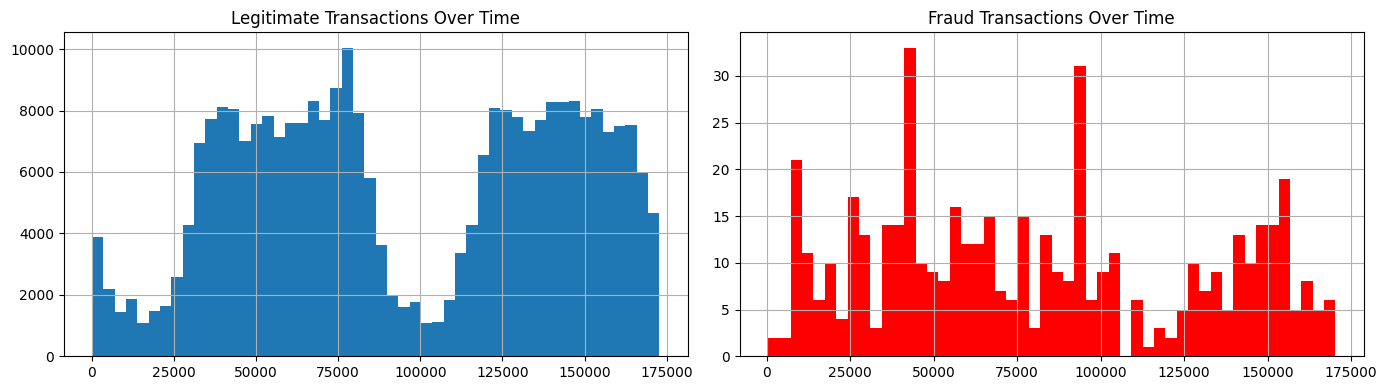

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df[df['Class'] == 0]['Time'].hist(bins=50, ax=axes[0])
axes[0].set_title('Legitimate Transactions Over Time')

df[df['Class'] == 1]['Time'].hist(bins=50, ax=axes[1], color='red')
axes[1].set_title('Fraud Transactions Over Time')

plt.tight_layout()
plt.show()

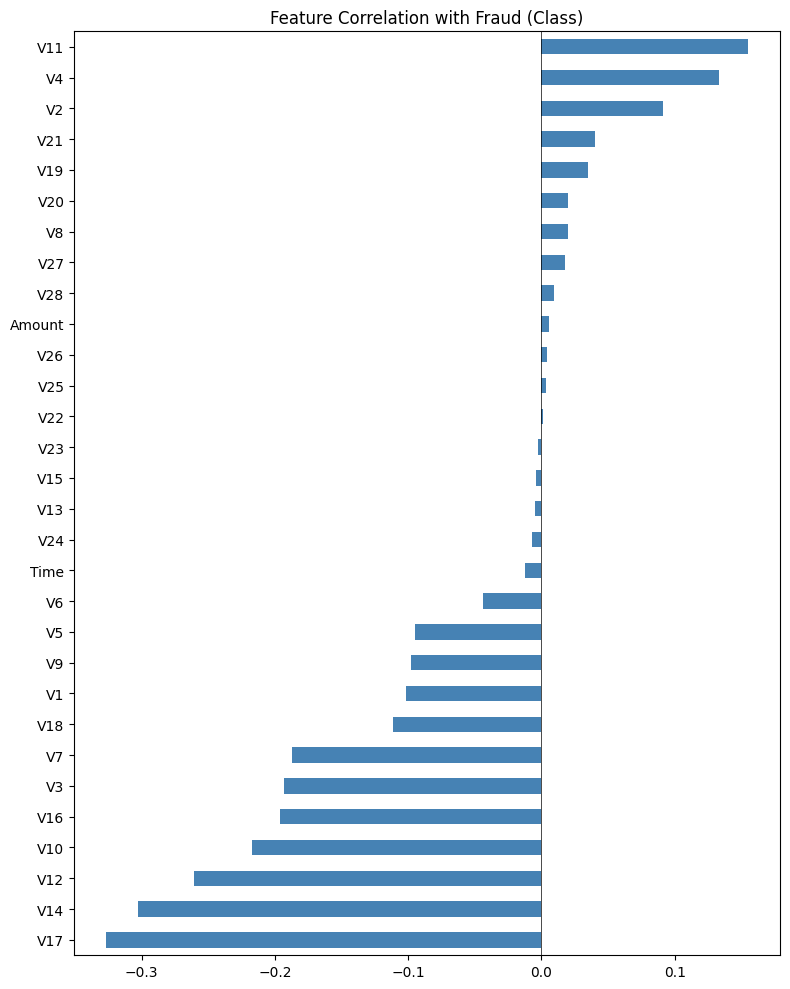

In [ ]:
plt.figure(figsize=(10, 8))
corr = df.corr()

# Only show correlation of all features WITH the Class column
fraud_corr = corr['Class'].drop('Class').sort_values()
fraud_corr.plot(kind='barh', figsize=(8, 10), color='steelblue')
plt.title('Feature Correlation with Fraud (Class)')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

## Day -2

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Split FIRST — before any resampling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"\nFraud in training: {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"Fraud in test: {y_test.sum()} ({y_test.mean()*100:.2f}%)")

Training set size: 227845
Test set size: 56962

Fraud in training: 394 (0.17%)
Fraud in test: 98 (0.17%)


In [ ]:
scaler = StandardScaler()

X_train = X_train.copy()
X_test = X_test.copy()

X_train[['Amount', 'Time']] = scaler.fit_transform(X_train[['Amount', 'Time']])
X_test[['Amount', 'Time']] = scaler.transform(X_test[['Amount', 'Time']])

print("Amount column after scaling:")
print(X_train['Amount'].describe().round(3))

Amount column after scaling:
count    227845.000
mean         -0.000
std           1.000
min          -0.352
25%          -0.329
50%          -0.264
75%          -0.043
max         102.117
Name: Amount, dtype: float64


=== BASELINE (No Imbalance Handling) ===
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC: 0.9559


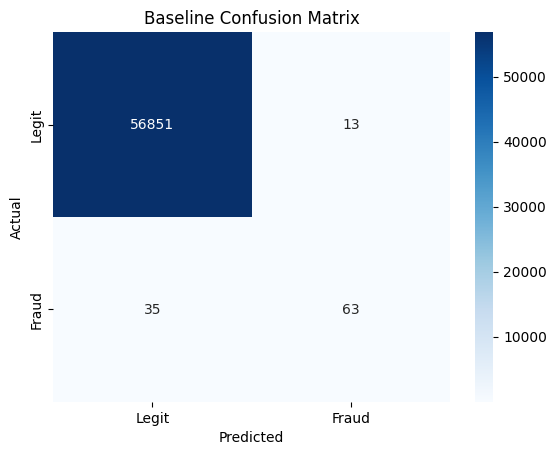

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Train with no imbalance handling
baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)

print("=== BASELINE (No Imbalance Handling) ===")
print(classification_report(y_test, y_pred_baseline, target_names=['Legit', 'Fraud']))
print(f"AUC-ROC: {roc_auc_score(y_test, baseline_model.predict_proba(X_test)[:,1]):.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_baseline)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'])
plt.title('Baseline Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

=== CLASS WEIGHTS ===
              precision    recall  f1-score   support

       Legit       1.00      0.98      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

AUC-ROC: 0.9722


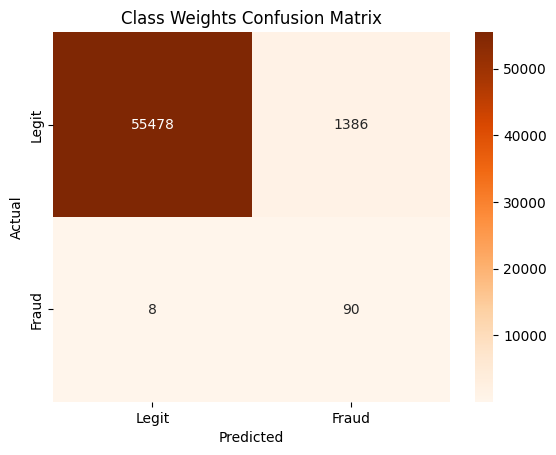

In [ ]:
# class_weight='balanced' auto-calculates weights based on class frequency
weighted_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
weighted_model.fit(X_train, y_train)
y_pred_weighted = weighted_model.predict(X_test)

print("=== CLASS WEIGHTS ===")
print(classification_report(y_test, y_pred_weighted, target_names=['Legit', 'Fraud']))
print(f"AUC-ROC: {roc_auc_score(y_test, weighted_model.predict_proba(X_test)[:,1]):.4f}")

cm = confusion_matrix(y_test, y_pred_weighted)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'])
plt.title('Class Weights Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

After undersampling:
Legit: 394, Fraud: 394

=== UNDERSAMPLING ===
              precision    recall  f1-score   support

       Legit       1.00      0.96      0.98     56864
       Fraud       0.04      0.92      0.07        98

    accuracy                           0.96     56962
   macro avg       0.52      0.94      0.53     56962
weighted avg       1.00      0.96      0.98     56962

AUC-ROC: 0.9759


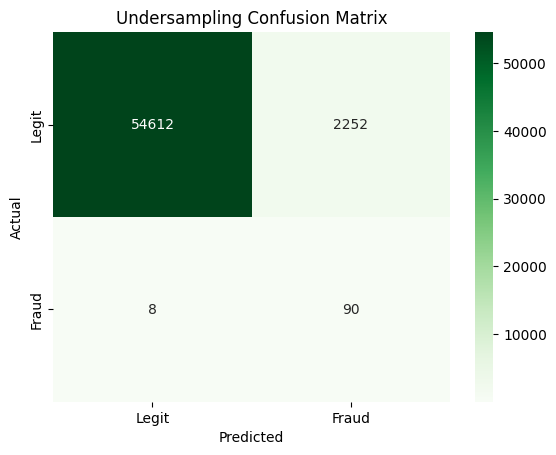

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print(f"After undersampling:")
print(f"Legit: {(y_train_under==0).sum()}, Fraud: {(y_train_under==1).sum()}")

under_model = LogisticRegression(max_iter=1000, random_state=42)
under_model.fit(X_train_under, y_train_under)
y_pred_under = under_model.predict(X_test)

print("\n=== UNDERSAMPLING ===")
print(classification_report(y_test, y_pred_under, target_names=['Legit', 'Fraud']))
print(f"AUC-ROC: {roc_auc_score(y_test, under_model.predict_proba(X_test)[:,1]):.4f}")

cm = confusion_matrix(y_test, y_pred_under)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'])
plt.title('Undersampling Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

After SMOTE:
Legit: 227451, Fraud: 227451

=== SMOTE ===
              precision    recall  f1-score   support

       Legit       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

AUC-ROC: 0.9699


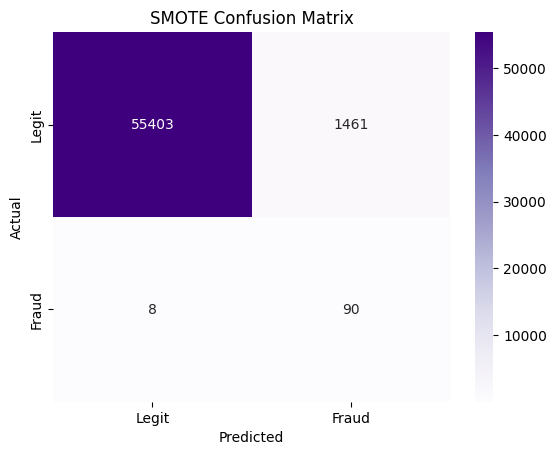

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"After SMOTE:")
print(f"Legit: {(y_train_smote==0).sum()}, Fraud: {(y_train_smote==1).sum()}")

smote_model = LogisticRegression(max_iter=1000, random_state=42)
smote_model.fit(X_train_smote, y_train_smote)
y_pred_smote = smote_model.predict(X_test)

print("\n=== SMOTE ===")
print(classification_report(y_test, y_pred_smote, target_names=['Legit', 'Fraud']))
print(f"AUC-ROC: {roc_auc_score(y_test, smote_model.predict_proba(X_test)[:,1]):.4f}")

cm = confusion_matrix(y_test, y_pred_smote)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'])
plt.title('SMOTE Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [ ]:
from sklearn.metrics import f1_score, recall_score, precision_score

results = {
    'Baseline': y_pred_baseline,
    'Class Weights': y_pred_weighted,
    'Undersampling': y_pred_under,
    'SMOTE': y_pred_smote
}

print(f"{'Approach':<20} {'Precision':>10} {'Recall':>10} {'F1':>10} {'AUC-ROC':>10}")
print("-" * 60)

models = {
    'Baseline': baseline_model,
    'Class Weights': weighted_model,
    'Undersampling': under_model,
    'SMOTE': smote_model
}

test_sets = {
    'Baseline': X_test,
    'Class Weights': X_test,
    'Undersampling': X_test,
    'SMOTE': X_test
}

for name, y_pred in results.items():
    p = precision_score(y_test, y_pred)
    r = recall_score(y_test, y_pred)
    f = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, models[name].predict_proba(test_sets[name])[:,1])
    print(f"{name:<20} {p:>10.3f} {r:>10.3f} {f:>10.3f} {auc:>10.4f}")

Approach              Precision     Recall         F1    AUC-ROC
------------------------------------------------------------
Baseline                  0.829      0.643      0.724     0.9559
Class Weights             0.061      0.918      0.114     0.9722
Undersampling             0.038      0.918      0.074     0.9759
SMOTE                     0.058      0.918      0.109     0.9699


In [ ]:
# Add back to original df before splitting in a new version
df['Amount_log'] = np.log1p(df['Amount'])  # log transform reduces skew

# Hour of day — fraudsters behave differently at night
df['Hour'] = (df['Time'] % 86400) // 3600

print(df[['Amount', 'Amount_log', 'Hour']].head(10))

   Amount  Amount_log  Hour
0  149.62    5.014760   0.0
1    2.69    1.305626   0.0
2  378.66    5.939276   0.0
3  123.50    4.824306   0.0
4   69.99    4.262539   0.0
5    3.67    1.541159   0.0
6    4.99    1.790091   0.0
7   40.80    3.732896   0.0
8   93.20    4.545420   0.0
9    3.68    1.543298   0.0


## Day-3

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, precision_recall_curve, f1_score,
                             precision_score, recall_score)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Load
df = pd.read_csv('/content/creditcard.csv')

# Feature engineering
df['Amount_log'] = np.log1p(df['Amount'])
df['Hour'] = (df['Time'] % 86400) // 3600

# Drop original Amount and Time (replaced by engineered versions)
df = df.drop(['Amount', 'Time'], axis=1)

# Split
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame (needed for SHAP feature names later)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# SMOTE — applied AFTER split, on training data only
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"Training set after SMOTE: {pd.Series(y_train_res).value_counts().to_dict()}")
print(f"Test set (untouched): {y_test.value_counts().to_dict()}")

Training set after SMOTE: {0: 227451, 1: 227451}
Test set (untouched): {0: 56864, 1: 98}


In [ ]:
xgb_model = XGBClassifier(
    n_estimators=300,       # number of trees
    max_depth=6,            # how deep each tree can go
    learning_rate=0.05,     # how much each tree contributes
    scale_pos_weight=1,     # 1 because we already handled imbalance with SMOTE
    eval_metric='logloss',
    random_state=42,
    use_label_encoder=False
)

xgb_model.fit(X_train_res, y_train_res)

# Get probability scores (not just 0/1 predictions)
xgb_probs = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Default threshold of 0.5
xgb_preds_default = (xgb_probs >= 0.5).astype(int)

print("=== XGBoost (Default Threshold 0.5) ===")
print(classification_report(y_test, xgb_preds_default, target_names=['Legit', 'Fraud']))
print(f"AUC-ROC: {roc_auc_score(y_test, xgb_probs):.4f}")

=== XGBoost (Default Threshold 0.5) ===
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.54      0.86      0.66        98

    accuracy                           1.00     56962
   macro avg       0.77      0.93      0.83     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC: 0.9800


In [ ]:
lgbm_model = LGBMClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    verbose=-1             # suppress training logs
)

lgbm_model.fit(X_train_res, y_train_res)

lgbm_probs = lgbm_model.predict_proba(X_test_scaled)[:, 1]
lgbm_preds_default = (lgbm_probs >= 0.5).astype(int)

print("=== LightGBM (Default Threshold 0.5) ===")
print(classification_report(y_test, lgbm_preds_default, target_names=['Legit', 'Fraud']))
print(f"AUC-ROC: {roc_auc_score(y_test, lgbm_probs):.4f}")

=== LightGBM (Default Threshold 0.5) ===
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.54      0.88      0.67        98

    accuracy                           1.00     56962
   macro avg       0.77      0.94      0.83     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC: 0.9807


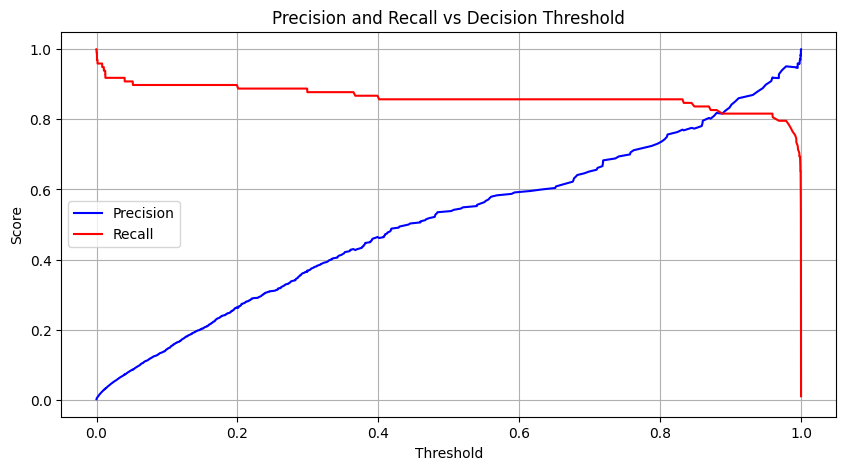

In [ ]:
# Use whichever model had better AUC-ROC — using XGBoost here as example
# Replace xgb_probs with lgbm_probs if LightGBM was better for you

precisions, recalls, thresholds = precision_recall_curve(y_test, xgb_probs)

# Plot Precision vs Recall at every threshold
plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions[:-1], label='Precision', color='blue')
plt.plot(thresholds, recalls[:-1], label='Recall', color='red')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall vs Decision Threshold')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Find the threshold that maximizes F1 score
f1_scores = []
threshold_range = np.arange(0.1, 0.9, 0.01)

for thresh in threshold_range:
    preds = (xgb_probs >= thresh).astype(int)
    f1 = f1_score(y_test, preds)
    f1_scores.append(f1)

best_idx = np.argmax(f1_scores)
best_threshold = threshold_range[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Best threshold: {best_threshold:.2f}")
print(f"Best F1 score at that threshold: {best_f1:.4f}")

# Now apply the best threshold
xgb_preds_tuned = (xgb_probs >= best_threshold).astype(int)

print("\n=== XGBoost (Tuned Threshold) ===")
print(classification_report(y_test, xgb_preds_tuned, target_names=['Legit', 'Fraud']))

Best threshold: 0.88
Best F1 score at that threshold: 0.8223

=== XGBoost (Tuned Threshold) ===
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.82      0.83      0.82        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962



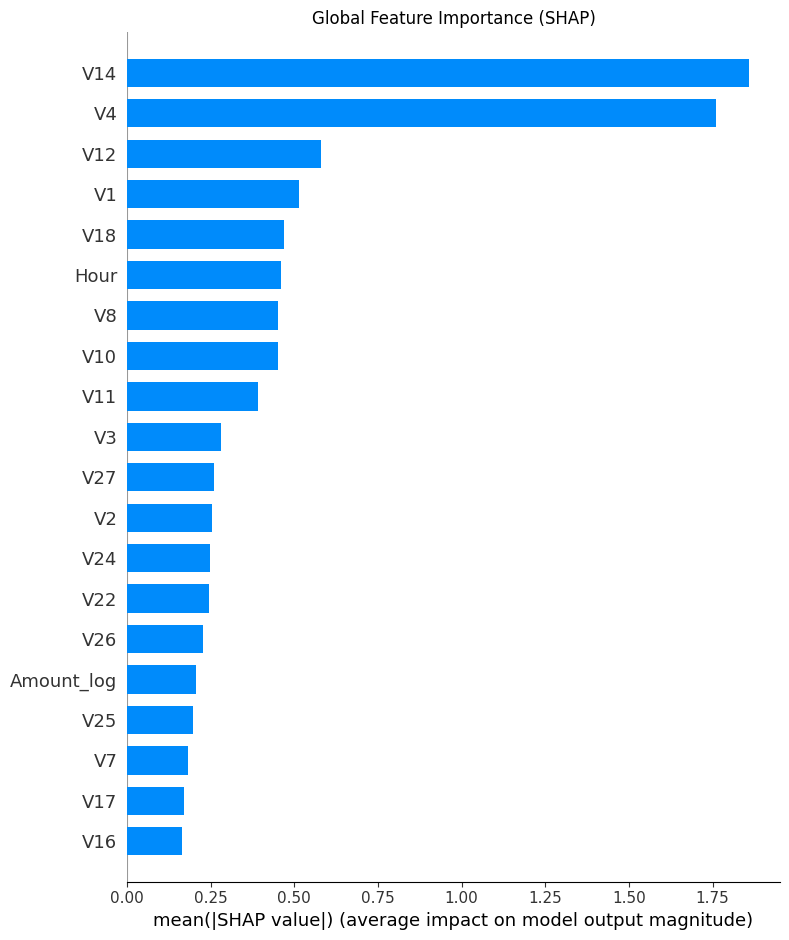

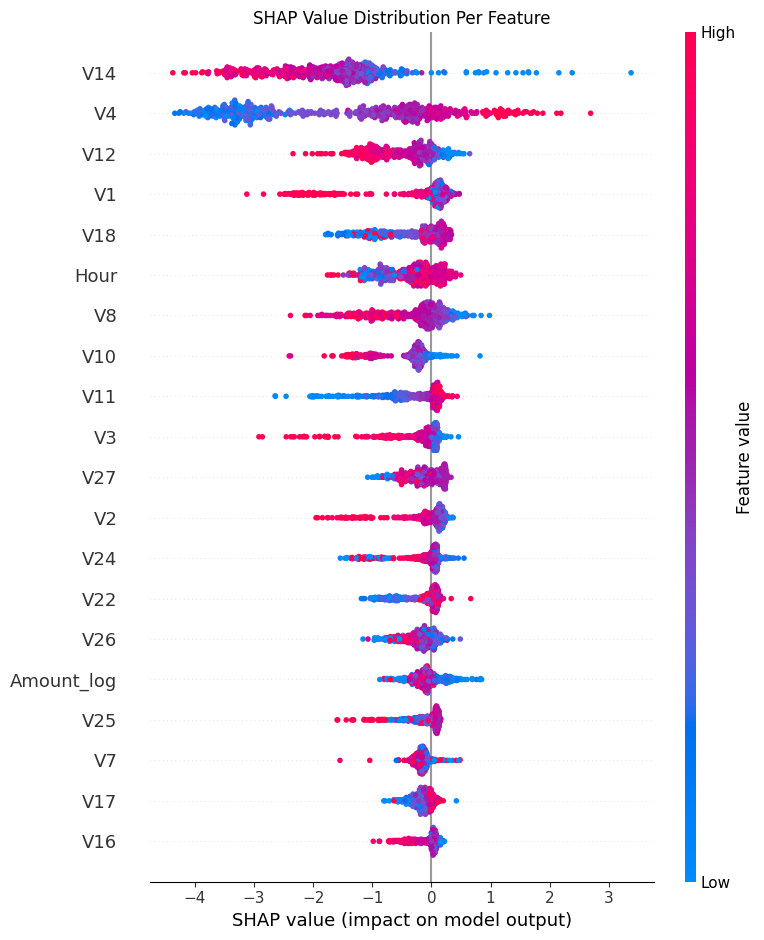

In [ ]:
# SHAP works best with tree models like XGBoost
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for test set
# Use a sample of 500 rows — full test set takes too long
X_test_sample = X_test_scaled.sample(500, random_state=42)
shap_values = explainer.shap_values(X_test_sample)

# Summary plot — shows feature importance with direction
plt.figure()
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)
plt.title("Global Feature Importance (SHAP)")
plt.tight_layout()
plt.show()

# Dot plot — shows whether high/low feature values push toward fraud or legit
plt.figure()
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.title("SHAP Value Distribution Per Feature")
plt.tight_layout()
plt.show()

Model's fraud probability for this transaction: 0.9998
Actual label: FRAUD


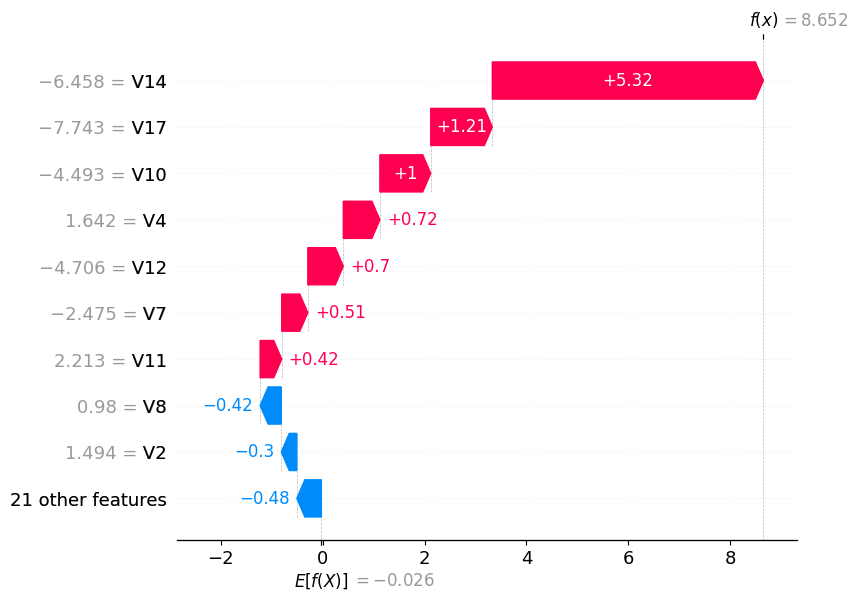

In [ ]:
# Pick a fraud transaction from test set to explain
fraud_indices = y_test[y_test == 1].index
sample_fraud_idx = fraud_indices[0]

# Get that transaction's position in our scaled test set
test_reset = X_test_scaled.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

fraud_position = y_test_reset[y_test_reset == 1].index[0]
single_transaction = test_reset.iloc[[fraud_position]]

# SHAP values for this one transaction
single_shap = explainer.shap_values(single_transaction)

print(f"Model's fraud probability for this transaction: {xgb_model.predict_proba(single_transaction)[0][1]:.4f}")
print(f"Actual label: {'FRAUD' if y_test_reset.iloc[fraud_position] == 1 else 'LEGIT'}")

# Waterfall plot — shows exactly how each feature pushed the prediction
shap.waterfall_plot(
    shap.Explanation(
        values=single_shap[0],
        base_values=explainer.expected_value,
        data=single_transaction.iloc[0],
        feature_names=X_test_scaled.columns.tolist()
    )
)

In [ ]:
print(f"\n{'Model':<30} {'Precision':>10} {'Recall':>10} {'F1':>10} {'AUC-ROC':>10}")
print("-" * 65)

comparisons = [
    ("XGBoost (threshold=0.5)", xgb_preds_default, xgb_probs),
    ("XGBoost (tuned threshold)", xgb_preds_tuned, xgb_probs),
    ("LightGBM (threshold=0.5)", lgbm_preds_default, lgbm_probs),
]

for name, preds, probs in comparisons:
    p = precision_score(y_test, preds)
    r = recall_score(y_test, preds)
    f = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)
    print(f"{name:<30} {p:>10.3f} {r:>10.3f} {f:>10.3f} {auc:>10.4f}")


Model                           Precision     Recall         F1    AUC-ROC
-----------------------------------------------------------------
XGBoost (threshold=0.5)             0.538      0.857      0.661     0.9800
XGBoost (tuned threshold)           0.818      0.827      0.822     0.9800
LightGBM (threshold=0.5)            0.541      0.878      0.669     0.9807


## Making the .pkl file

In [ ]:
import joblib
from google.colab import files
import json
import os

# Create the models directory if it doesn't exist
output_dir = '../models/'
os.makedirs(output_dir, exist_ok=True)

# Define file paths
lgbm_model_path = os.path.join(output_dir, 'lgbm_model.pkl')
scaler_path = os.path.join(output_dir, 'scaler.pkl')
feature_names_path = os.path.join(output_dir, 'feature_names.json')

# Save the LightGBM model
joblib.dump(lgbm_model, lgbm_model_path)

# Save the scaler
joblib.dump(scaler, scaler_path)

# Save the feature names (you'll need these in the API)
feature_names = X_train.columns.tolist()
with open(feature_names_path, 'w') as f:
    json.dump(feature_names, f)

print("Model, scaler and feature names saved successfully to Colab environment.")
print(f"Features: {feature_names}")

# Download the saved files to your local machine
print("\nDownloading files...")
files.download(lgbm_model_path)
files.download(scaler_path)
files.download(feature_names_path)
print("Files downloaded.")

Model, scaler and feature names saved successfully to Colab environment.
Features: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount_log', 'Hour']



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Files downloaded.
